# Livrable 5 — Rapport analytique par agrégations

Objectif : répondre à trois questions de sécurité routière compréhensibles sans connaître la structure BAAC.

1. La part d'usagers tués varie-t-elle selon l'heure et entre semaine et week-end ?
2. Quels modes de déplacement présentent la plus forte proportion d'usagers tués ou hospitalisés ?
3. Quels types de routes ont le plus d'accidents corporels et quelle part de ces accidents est mortelle ?

Les calculs métier sont faits dans MongoDB avec des pipelines d'agrégation.  
Pandas et Matplotlib servent uniquement à afficher les résultats et les graphiques.


In [1]:
from pymongo import MongoClient
from dotenv import dotenv_values
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
# Connexion à la base finale Atlas
env_vars = dotenv_values(".env")
env_local_vars = dotenv_values(".env.local")

atlas_uri = env_vars.get("ATLAS_URI") or env_local_vars.get("ATLAS_URI")

if not atlas_uri:
    raise ValueError("ATLAS_URI introuvable dans .env ou .env.local")

client = MongoClient(atlas_uri, serverSelectionTimeoutMS=5000)
client.admin.command("ping")

db = client["securite_routiere"]
accidents = db["accidents"]

print("Connexion Atlas : OK")
print("Documents dans la collection :", accidents.count_documents({}))


Connexion Atlas : OK
Documents dans la collection : 54407


## Contrôle de la collection

Pendant les tests du projet, quelques doublons ont pu être ajoutés sur la base partagée.

Les analyses commencent donc par garder un seul document par `Num_Acc`.  
Cela évite qu'un accident de test soit compté plusieurs fois et reste cohérent avec notre modèle : **un document = un accident**.


In [3]:
controle = list(accidents.aggregate([
    {
        "$group": {
            "_id": "$Num_Acc",
            "n": {"$sum": 1}
        }
    },
    {
        "$group": {
            "_id": None,
            "documents": {"$sum": "$n"},
            "accidents_distincts": {"$sum": 1},
            "doublons_tests": {
                "$sum": {"$subtract": ["$n", 1]}
            }
        }
    },
    {"$project": {"_id": 0}}
]))

pd.DataFrame(controle)


,documents,accidents_distincts,doublons_tests
0,54407,54402,5


In [4]:
# Ces deux étapes sont réutilisées au début de chaque analyse.
deduplication = [
    {
        "$group": {
            "_id": "$Num_Acc",
            "accident": {"$first": "$$ROOT"}
        }
    },
    {"$replaceRoot": {"newRoot": "$accident"}}
]


# 1 — Heure et week-end

## Question métier

**La part d'usagers tués varie-t-elle selon l'heure et entre semaine et week-end ?**

On ne compare pas seulement le nombre d'accidents : on calcule la proportion d'usagers tués parmi les usagers impliqués pour chaque heure et chaque période.

`$unwind` est nécessaire car les usagers sont stockés dans `vehicules[].usagers[]`.


In [5]:
pipeline_horaire = [
    *deduplication,

    {"$match": {"date": {"$type": "date"}}},
    {"$unwind": "$vehicules"},
    {"$unwind": "$vehicules.usagers"},

    {
        "$project": {
            "heure": {"$hour": "$date"},
            "jour_semaine": {"$dayOfWeek": "$date"},
            "est_tue": {
                "$cond": [
                    {"$eq": ["$vehicules.usagers.grav", 2]},
                    1,
                    0
                ]
            }
        }
    },

    {
        "$project": {
            "heure": 1,
            "est_tue": 1,
            "periode": {
                "$cond": [
                    {"$in": ["$jour_semaine", [1, 7]]},
                    "Week-end",
                    "Semaine"
                ]
            }
        }
    },

    {
        "$group": {
            "_id": {
                "periode": "$periode",
                "heure": "$heure"
            },
            "total_usagers": {"$sum": 1},
            "usagers_tues": {"$sum": "$est_tue"}
        }
    },

    {
        "$project": {
            "_id": 0,
            "periode": "$_id.periode",
            "heure": "$_id.heure",
            "total_usagers": 1,
            "usagers_tues": 1,
            "part_usagers_tues_pct": {
                "$multiply": [
                    {"$divide": ["$usagers_tues", "$total_usagers"]},
                    100
                ]
            }
        }
    },

    {"$sort": {"periode": 1, "heure": 1}}
]

df_horaire = pd.DataFrame(list(accidents.aggregate(pipeline_horaire)))
df_horaire["part_usagers_tues_pct"] = df_horaire["part_usagers_tues_pct"].round(2)

df_horaire


,total_usagers,usagers_tues,periode,heure,part_usagers_tues_pct
0,1330,55,Semaine,0,4.14
1,961,44,Semaine,1,4.58
2,730,34,Semaine,2,4.66
3,585,47,Semaine,3,8.03
4,653,30,Semaine,4,4.59
5,978,77,Semaine,5,7.87
6,1690,68,Semaine,6,4.02
7,4563,93,Semaine,7,2.04
8,6288,122,Semaine,8,1.94
9,4823,110,Semaine,9,2.28


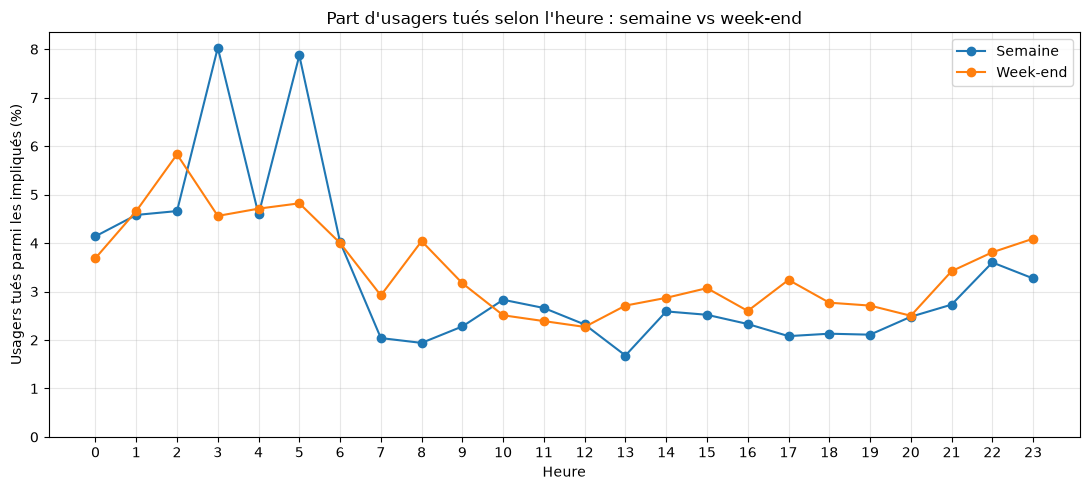

In [6]:
fig, ax = plt.subplots(figsize=(11, 5))

for periode, groupe in df_horaire.groupby("periode"):
    groupe = groupe.sort_values("heure")
    ax.plot(
        groupe["heure"],
        groupe["part_usagers_tues_pct"],
        marker="o",
        label=periode
    )

ax.set_title("Part d'usagers tués selon l'heure : semaine vs week-end")
ax.set_xlabel("Heure")
ax.set_ylabel("Usagers tués parmi les impliqués (%)")
ax.set_xticks(range(24))
ax.set_ylim(bottom=0)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [7]:
pics_horaires = (
    df_horaire.loc[
        df_horaire.groupby("periode")["part_usagers_tues_pct"].idxmax(),
        ["periode", "heure", "total_usagers", "usagers_tues", "part_usagers_tues_pct"]
    ]
    .sort_values("periode")
)

print("Pic observé pour chaque période :")
display(pics_horaires)


Pic observé pour chaque période :


,periode,heure,total_usagers,usagers_tues,part_usagers_tues_pct
3,Semaine,3,585,47,8.03
26,Week-end,2,1046,61,5.83


### À défendre à l'oral

- `$unwind` transforme les tableaux imbriqués en lignes d'usagers pour pouvoir compter leur gravité.
- `grav = 2` signifie **tué** dans la documentation BAAC.
- Le dénominateur est le nombre d'**usagers impliqués**, donc ce graphique ne mesure pas le risque d'avoir un accident.
- Les effectifs sont conservés dans le tableau pour ne pas surinterpréter un pourcentage calculé sur peu d'observations.


# 2 — Vulnérabilité selon le mode de déplacement

## Question métier

**Quels modes de déplacement présentent la plus forte proportion d'usagers tués ou hospitalisés ?**

Une issue est considérée ici comme grave lorsque `grav` vaut :
- `2` : tué ;
- `3` : blessé hospitalisé.

Modes retenus pour garder une comparaison lisible :
- piéton ;
- vélo ;
- deux-roues motorisé ;
- voiture légère.


In [8]:
pipeline_modes = [
    *deduplication,

    {"$unwind": "$vehicules"},
    {"$unwind": "$vehicules.usagers"},

    {
        "$project": {
            "grav": "$vehicules.usagers.grav",

            "mode_transport": {
                "$switch": {
                    "branches": [
                        {
                            "case": {"$eq": ["$vehicules.usagers.catu", 3]},
                            "then": "Piéton"
                        },
                        {
                            "case": {"$eq": ["$vehicules.catv", 1]},
                            "then": "Vélo"
                        },
                        {
                            "case": {
                                "$in": [
                                    "$vehicules.catv",
                                    [2, 30, 31, 32, 33, 34]
                                ]
                            },
                            "then": "Deux-roues motorisé"
                        },
                        {
                            "case": {"$eq": ["$vehicules.catv", 7]},
                            "then": "Voiture légère"
                        }
                    ],
                    "default": None
                }
            }
        }
    },

    {
        "$match": {
            "mode_transport": {"$ne": None},
            "grav": {"$in": [1, 2, 3, 4]}
        }
    },

    {
        "$group": {
            "_id": "$mode_transport",
            "total_usagers": {"$sum": 1},
            "usagers_graves": {
                "$sum": {
                    "$cond": [
                        {"$in": ["$grav", [2, 3]]},
                        1,
                        0
                    ]
                }
            },
            "usagers_tues": {
                "$sum": {
                    "$cond": [
                        {"$eq": ["$grav", 2]},
                        1,
                        0
                    ]
                }
            }
        }
    },

    {
        "$project": {
            "_id": 0,
            "mode_transport": "$_id",
            "total_usagers": 1,
            "usagers_graves": 1,
            "usagers_tues": 1,
            "part_grave_pct": {
                "$multiply": [
                    {"$divide": ["$usagers_graves", "$total_usagers"]},
                    100
                ]
            }
        }
    },

    {"$sort": {"part_grave_pct": -1}}
]

df_modes = pd.DataFrame(list(accidents.aggregate(pipeline_modes)))
df_modes["part_grave_pct"] = df_modes["part_grave_pct"].round(2)

df_modes


,total_usagers,usagers_graves,usagers_tues,mode_transport,part_grave_pct
0,18851,6739,782,Deux-roues motorisé,35.75
1,9401,3089,498,Piéton,32.86
2,5095,1404,201,Vélo,27.56
3,71778,9003,1604,Voiture légère,12.54


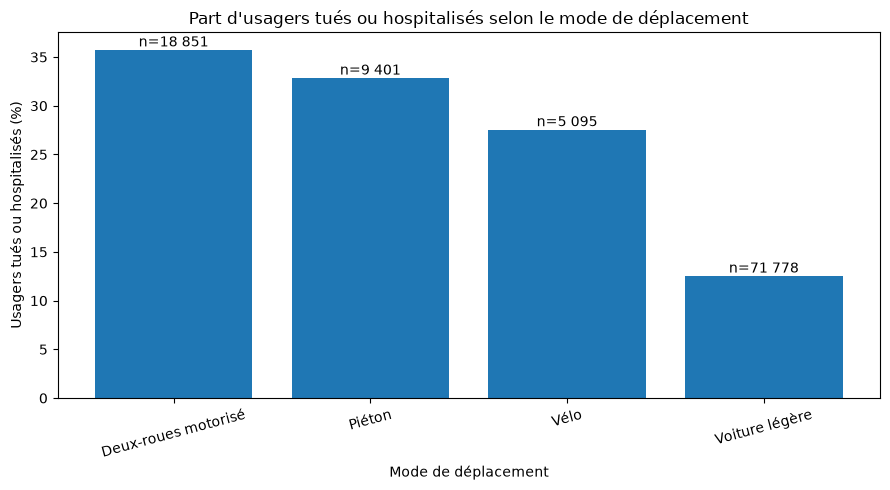

In [9]:
df_modes_plot = df_modes.sort_values("part_grave_pct", ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    df_modes_plot["mode_transport"],
    df_modes_plot["part_grave_pct"]
)

ax.set_title("Part d'usagers tués ou hospitalisés selon le mode de déplacement")
ax.set_xlabel("Mode de déplacement")
ax.set_ylabel("Usagers tués ou hospitalisés (%)")
ax.set_ylim(bottom=0)

for bar, total in zip(bars, df_modes_plot["total_usagers"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"n={int(total):,}".replace(",", " "),
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


In [10]:
mode_plus_grave = df_modes.iloc[0]

print(
    "Part la plus élevée :",
    mode_plus_grave["mode_transport"],
    "-",
    f'{mode_plus_grave["part_grave_pct"]:.2f}%'
)


Part la plus élevée : Deux-roues motorisé - 35.75%


### À défendre à l'oral

- Le calcul de gravité est fait directement dans MongoDB, pas dans Pandas.
- Les catégories de véhicules viennent des codes BAAC (`catv`).
- Le code `2` a été ajouté aux deux-roues motorisés car il correspond au cyclomoteur de moins de 50 cm³ ; les codes `30` à `34` couvrent les scooters et motocyclettes.
- On mesure la **gravité parmi les usagers déjà impliqués dans un accident**. Sans données d'exposition (kilomètres parcourus, nombre d'usagers en circulation), on ne peut pas conclure qu'un mode a plus de risque d'avoir un accident.


# 3 — Type de route et accidents mortels

## Question métier

**Quels types de routes ont le plus d'accidents corporels et quelle part de ces accidents est mortelle ?**

Ici l'unité d'analyse redevient l'**accident**.

Un accident est considéré comme mortel si au moins un de ses usagers a `grav = 2`.  
Même s'il y a plusieurs personnes tuées dans le même accident, l'accident n'est compté qu'une seule fois.


In [11]:
pipeline_routes = [
    *deduplication,

    {
        "$match": {
            "lieu.catr": {"$in": [1, 2, 3, 4]}
        }
    },

    {"$unwind": "$vehicules"},
    {"$unwind": "$vehicules.usagers"},

    # On revient à une ligne par accident avant de calculer le taux.
    {
        "$group": {
            "_id": {
                "Num_Acc": "$Num_Acc",
                "catr": "$lieu.catr"
            },
            "accident_mortel": {
                "$max": {
                    "$cond": [
                        {"$eq": ["$vehicules.usagers.grav", 2]},
                        1,
                        0
                    ]
                }
            }
        }
    },

    {
        "$group": {
            "_id": "$_id.catr",
            "nombre_accidents": {"$sum": 1},
            "accidents_mortels": {"$sum": "$accident_mortel"}
        }
    },

    {
        "$project": {
            "_id": 0,

            "type_route": {
                "$switch": {
                    "branches": [
                        {"case": {"$eq": ["$_id", 1]}, "then": "Autoroute"},
                        {"case": {"$eq": ["$_id", 2]}, "then": "Route nationale"},
                        {"case": {"$eq": ["$_id", 3]}, "then": "Route départementale"},
                        {"case": {"$eq": ["$_id", 4]}, "then": "Voie communale"}
                    ],
                    "default": "Autre"
                }
            },

            "nombre_accidents": 1,
            "accidents_mortels": 1,

            "part_accidents_mortels_pct": {
                "$multiply": [
                    {"$divide": ["$accidents_mortels", "$nombre_accidents"]},
                    100
                ]
            }
        }
    },

    {"$sort": {"part_accidents_mortels_pct": -1}}
]

df_routes = pd.DataFrame(list(accidents.aggregate(pipeline_routes)))
df_routes["part_accidents_mortels_pct"] = df_routes["part_accidents_mortels_pct"].round(2)

df_routes


,nombre_accidents,accidents_mortels,type_route,part_accidents_mortels_pct
0,20658,1914,Route départementale,9.27
1,3531,281,Route nationale,7.96
2,5092,226,Autoroute,4.44
3,22910,668,Voie communale,2.92


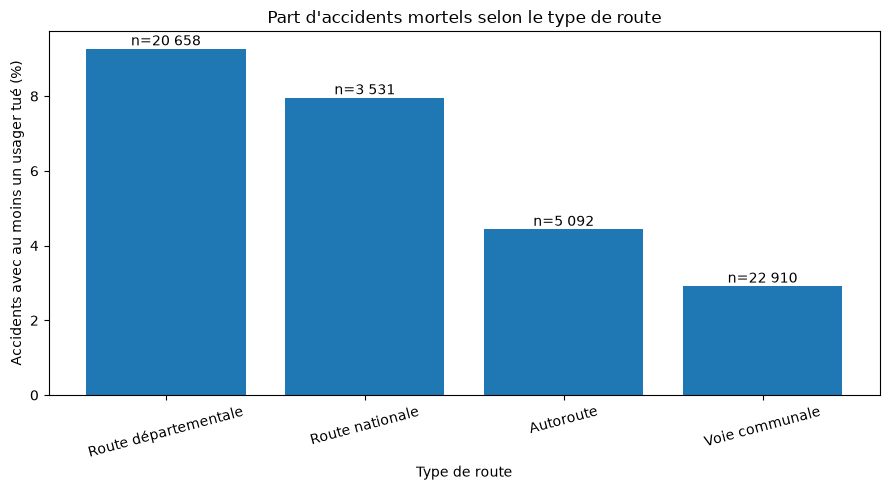

In [12]:
df_routes_plot = df_routes.sort_values(
    "part_accidents_mortels_pct",
    ascending=False
)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(
    df_routes_plot["type_route"],
    df_routes_plot["part_accidents_mortels_pct"]
)

ax.set_title("Part d'accidents mortels selon le type de route")
ax.set_xlabel("Type de route")
ax.set_ylabel("Accidents avec au moins un usager tué (%)")
ax.set_ylim(bottom=0)

for bar, total in zip(bars, df_routes_plot["nombre_accidents"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"n={int(total):,}".replace(",", " "),
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


In [13]:
route_plus_mortelle = df_routes.sort_values(
    "part_accidents_mortels_pct",
    ascending=False
).iloc[0]

route_plus_accidentee = df_routes.sort_values(
    "nombre_accidents",
    ascending=False
).iloc[0]

print(
    "Part d'accidents mortels la plus élevée :",
    route_plus_mortelle["type_route"],
    "-",
    f'{route_plus_mortelle["part_accidents_mortels_pct"]:.2f}%'
)

print(
    "Plus grand volume d'accidents :",
    route_plus_accidentee["type_route"],
    "-",
    int(route_plus_accidentee["nombre_accidents"]),
    "accidents"
)


Part d'accidents mortels la plus élevée : Route départementale - 9.27%
Plus grand volume d'accidents : Voie communale - 22910 accidents


### À défendre à l'oral

- On fait d'abord `$unwind` pour lire la gravité des usagers.
- Puis on regroupe par `Num_Acc` avec `$max` : dès qu'un usager est tué, `accident_mortel` vaut 1.
- On regroupe ensuite par type de route. C'est cette deuxième agrégation qui calcule la part d'accidents mortels.
- Cette méthode évite de compter plusieurs fois un accident qui comporte plusieurs véhicules ou plusieurs personnes tuées.


# Limites à annoncer

- Le BAAC décrit les **accidents corporels** relevés par les forces de l'ordre, pas tous les incidents de circulation.
- Les résultats sont descriptifs : une association observée ne prouve pas une cause.
- Pour les modes de déplacement, nous n'avons pas de mesure d'exposition comme les kilomètres parcourus : on compare la gravité **conditionnellement à l'implication dans un accident**.
- Le BAAC est une base brute : certains champs peuvent être absents ou non renseignés.
- Les doublons présents pendant nos tests sont neutralisés par `Num_Acc` avant chaque analyse.

Ces limites sont volontairement indiquées plutôt que de présenter les résultats comme plus précis qu'ils ne le sont.


In [14]:
client.close()
print("Connexion fermée")


Connexion fermée
